## Import Libraries

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option('display.max_columns', None)

## 1. Problem Statement

To predict the car price using various variables

Dependent Variables : Price
    
Independent Variable : 'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg'

## 2. Data Gathering

In [2]:
df_autos = pd.read_csv('autos_dataset.csv')
df_autos.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [3]:
df_autos.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [4]:
df_autos.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,?,?,?,164,164
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
engine-location,front,front,front,front,front
wheel-base,88.6,88.6,94.5,99.8,99.4


In [5]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

## 3. Exploratory Data Analysis

In [6]:
df_autos.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [7]:
df_autos[df_autos['normalized-losses'] == '?'].shape

(41, 26)

In [8]:
df_autos[df_autos == '?'].shape

(205, 26)

In [9]:
df_autos.replace({'?':np.nan}, inplace=True)
df_autos.isna().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [10]:
df_autos.isna().mean()*100

symboling             0.00000
normalized-losses    20.00000
make                  0.00000
fuel-type             0.00000
aspiration            0.00000
num-of-doors          0.97561
body-style            0.00000
drive-wheels          0.00000
engine-location       0.00000
wheel-base            0.00000
length                0.00000
width                 0.00000
height                0.00000
curb-weight           0.00000
engine-type           0.00000
num-of-cylinders      0.00000
engine-size           0.00000
fuel-system           0.00000
bore                  1.95122
stroke                1.95122
compression-ratio     0.00000
horsepower            0.97561
peak-rpm              0.97561
city-mpg              0.00000
highway-mpg           0.00000
price                 1.95122
dtype: float64

In [11]:
df_autos.duplicated().sum()

0

### Target --> Price

In [12]:
df_autos['price'] = df_autos['price'].astype(float)
df_autos['price'] = df_autos['price'].fillna(df_autos['price'].mean())
df_autos['price'] = df_autos['price'].astype(int)

### 3.1 symboling

In [13]:
df_autos['symboling']

0      3
1      3
2      1
3      2
4      2
      ..
200   -1
201   -1
202   -1
203   -1
204   -1
Name: symboling, Length: 205, dtype: int64

In [14]:
df_autos['symboling'].nunique()

6

In [15]:
df_autos['symboling'].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64

In [16]:
df_autos.groupby('symboling')[['price']].mean()

,price
symboling,
-2,15781.666667
-1,17330.681818
0,14361.567164
1,9780.444444
2,10109.281250
3,17221.296296


In [17]:
df_autos['symboling'] = np.where(df_autos['symboling']== -2, -1, df_autos['symboling'])
df_autos['symboling'].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    25
Name: count, dtype: int64

### 3.2 normalized-losses

In [18]:
df_autos['normalized-losses']

0      NaN
1      NaN
2      NaN
3      164
4      164
      ... 
200     95
201     95
202     95
203     95
204     95
Name: normalized-losses, Length: 205, dtype: object

mean >> If outliers are not present
median >> If outliers are present
KNN Imputer/Mice Imputer/Simple Imputer >> Small dataset with more than 10-15%

Null Value Ratio >> Fill Ratio

30% or more >> Drop Column

In [19]:
df_autos.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.848780,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220,13207.126829
std,1.217342,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443,7868.768212
min,-1.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10595.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [20]:
df_autos['normalized-losses'] = df_autos['normalized-losses'].astype(float)
df_autos['normalized-losses'].mean()

122.0

In [21]:
df_autos['normalized-losses'].median()

115.0

<Axes: >

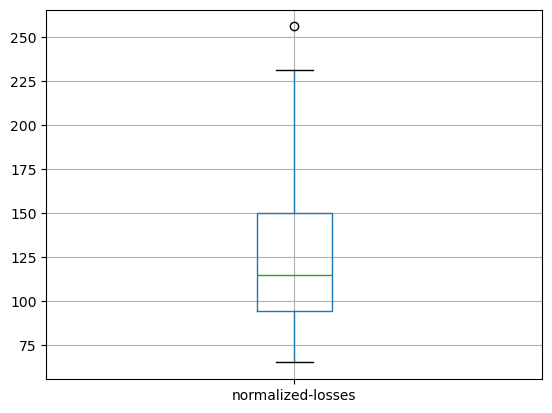

In [22]:
df_autos.boxplot('normalized-losses')

In [23]:
df_autos['normalized-losses'] = df_autos['normalized-losses'].fillna(df_autos['normalized-losses'].median())
df_autos['normalized-losses'] = df_autos['normalized-losses'].astype(int)

### 3.3 make

In [24]:
df_autos['make']

0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: make, Length: 205, dtype: object

In [25]:
df_autos['make'].nunique()

22

In [26]:
df_autos['make'].value_counts()

make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
volkswagen       12
subaru           12
peugot           11
volvo            11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
jaguar            3
chevrolet         3
alfa-romero       3
renault           2
mercury           1
Name: count, dtype: int64

### 3.4 Fuel-Type

In [27]:
df_autos['fuel-type']

0         gas
1         gas
2         gas
3         gas
4         gas
        ...  
200       gas
201       gas
202       gas
203    diesel
204       gas
Name: fuel-type, Length: 205, dtype: object

In [28]:
df_autos['fuel-type'].value_counts()

fuel-type
gas       185
diesel     20
Name: count, dtype: int64

In [29]:
df_autos['fuel-type'].replace({'diesel':0, 'gas':1}, inplace=True)
df_autos['fuel-type']

0      1
1      1
2      1
3      1
4      1
      ..
200    1
201    1
202    1
203    0
204    1
Name: fuel-type, Length: 205, dtype: int64

### 3.5 Aspiration

In [30]:
df_autos['aspiration']

0        std
1        std
2        std
3        std
4        std
       ...  
200      std
201    turbo
202      std
203    turbo
204    turbo
Name: aspiration, Length: 205, dtype: object

In [31]:
df_autos['aspiration'].value_counts()

aspiration
std      168
turbo     37
Name: count, dtype: int64

In [32]:
df_autos['aspiration'].replace({'turbo':0, 'std':1}, inplace=True)
df_autos['aspiration']

0      1
1      1
2      1
3      1
4      1
      ..
200    1
201    0
202    1
203    0
204    0
Name: aspiration, Length: 205, dtype: int64

### 3.6 Num-of-Doors

In [33]:
df_autos['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

In [34]:
df_autos['num-of-doors'].value_counts().to_dict()

{'four': 114, 'two': 89}

In [35]:
df_autos['num-of-doors'].replace({'four':4, 'two':2}, inplace=True)
df_autos['num-of-doors']

0      2.0
1      2.0
2      2.0
3      4.0
4      4.0
      ... 
200    4.0
201    4.0
202    4.0
203    4.0
204    4.0
Name: num-of-doors, Length: 205, dtype: float64

In [36]:
df_autos['num-of-doors'].fillna(df_autos['num-of-doors'].mode()[0], inplace=True)
df_autos['num-of-doors'] = df_autos['num-of-doors'].astype(int)

### 3.7 Body-Style

In [37]:
df_autos['body-style'].value_counts()

body-style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [38]:
df_autos.groupby('body-style')['price'].mean()

body-style
convertible    21890.500000
hardtop        22208.500000
hatchback      10050.285714
sedan          14433.656250
wagon          12371.960000
Name: price, dtype: float64

In [39]:
df_autos = pd.get_dummies(df_autos, columns=['body-style'], drop_first=True, dtype=int)
df_autos

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,3,115,alfa-romero,1,1,2,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495,0,0,0,0
1,3,115,alfa-romero,1,1,2,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500,0,0,0,0
2,1,115,alfa-romero,1,1,2,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500,0,1,0,0
3,2,164,audi,1,1,4,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950,0,0,1,0
4,2,164,audi,1,1,4,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,1,1,4,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845,0,0,1,0
201,-1,95,volvo,1,0,4,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045,0,0,1,0
202,-1,95,volvo,1,1,4,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485,0,0,1,0
203,-1,95,volvo,0,0,4,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470,0,0,1,0


### 3.8 Drive-Wheels

In [40]:
df_autos['drive-wheels'].value_counts()

drive-wheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

In [41]:
df_autos['drive-wheels'].value_counts().to_dict()

{'fwd': 120, 'rwd': 76, '4wd': 9}

In [42]:
df_autos['price'] = pd.to_numeric(df_autos['price'], errors='coerce') # Group by 'drive-wheels' and calculate the mean price 
mean_prices = df_autos.groupby('drive-wheels')['price'].mean()
mean_prices

drive-wheels
4wd    10570.555556
fwd     9310.816667
rwd    19671.421053
Name: price, dtype: float64

In [43]:
df_autos['drive-wheels'].replace({'fwd': 0, 'rwd': 2, '4wd': 1}, inplace=True)
df_autos['drive-wheels']

0      2
1      2
2      2
3      0
4      1
      ..
200    2
201    2
202    2
203    2
204    2
Name: drive-wheels, Length: 205, dtype: int64

### 3.9 Engine-Location

In [44]:
df_autos['engine-location'].value_counts()

engine-location
front    202
rear       3
Name: count, dtype: int64

In [45]:
df_autos['engine-location'].replace({'front': 1, 'rear': 0,}, inplace=True)
df_autos['engine-location']

0      1
1      1
2      1
3      1
4      1
      ..
200    1
201    1
202    1
203    1
204    1
Name: engine-location, Length: 205, dtype: int64

### 3.10 Wheel-Base

In [46]:
df_autos['wheel-base']

0       88.6
1       88.6
2       94.5
3       99.8
4       99.4
       ...  
200    109.1
201    109.1
202    109.1
203    109.1
204    109.1
Name: wheel-base, Length: 205, dtype: float64

<Axes: ylabel='Density'>

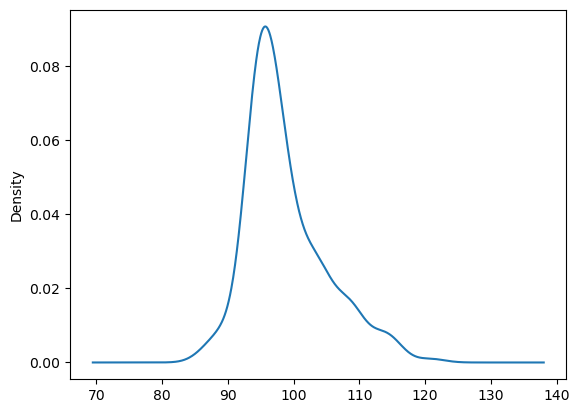

In [47]:
df_autos['wheel-base'].plot(kind = 'kde')

In [48]:
df_autos['wheel-base'].skew()

1.0502137758714858

<Axes: >

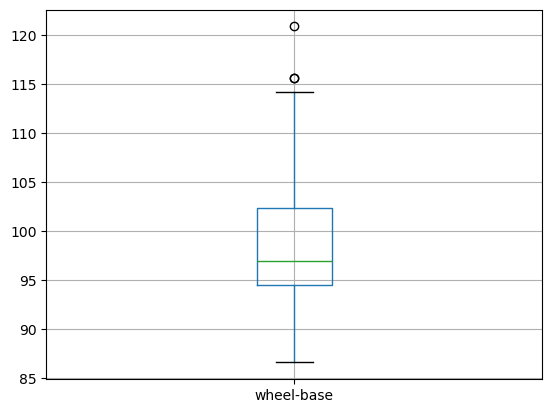

In [49]:
df_autos.boxplot('wheel-base')

<Axes: >

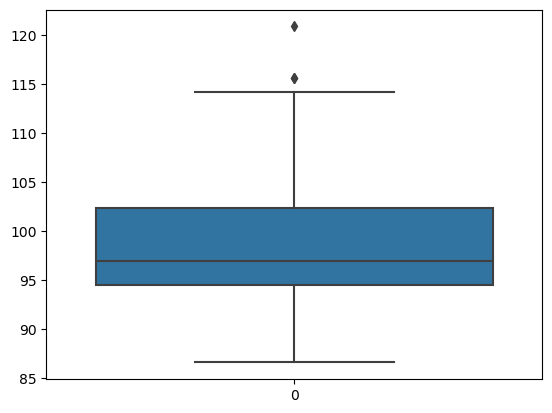

In [50]:
sns.boxplot(df_autos['wheel-base'])

In [51]:
df_autos[df_autos['wheel-base'] >= 114]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
70,-1,93,mercedes-benz,0,0,4,2,1,115.6,202.6,71.7,56.3,3770,ohc,five,183,idi,3.58,3.64,21.5,123,4350,22,25,31600,0,0,1,0
71,-1,115,mercedes-benz,1,1,4,2,1,115.6,202.6,71.7,56.5,3740,ohcv,eight,234,mpfi,3.46,3.1,8.3,155,4750,16,18,34184,0,0,1,0
73,0,115,mercedes-benz,1,1,4,2,1,120.9,208.1,71.7,56.7,3900,ohcv,eight,308,mpfi,3.8,3.35,8.0,184,4500,14,16,40960,0,0,1,0
109,0,115,peugot,1,1,4,2,1,114.2,198.9,68.4,58.7,3230,l,four,120,mpfi,3.46,3.19,8.4,97,5000,19,24,12440,0,0,0,1
110,0,115,peugot,0,0,4,2,1,114.2,198.9,68.4,58.7,3430,l,four,152,idi,3.7,3.52,21.0,95,4150,25,25,13860,0,0,0,1
113,0,115,peugot,1,1,4,2,1,114.2,198.9,68.4,56.7,3285,l,four,120,mpfi,3.46,2.19,8.4,95,5000,19,24,16695,0,0,0,1
114,0,115,peugot,0,0,4,2,1,114.2,198.9,68.4,58.7,3485,l,four,152,idi,3.7,3.52,21.0,95,4150,25,25,17075,0,0,0,1


In [52]:
df_autos['wheel-base']  = np.where(df_autos['wheel-base'] >= 114, df_autos['wheel-base'].median(), df_autos['wheel-base'])

### 3.11 Length

<Axes: xlabel='length', ylabel='Density'>

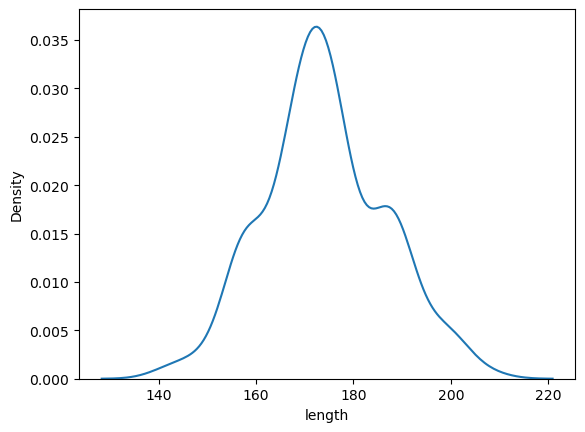

In [53]:
sns.kdeplot(df_autos['length'])

In [54]:
df_autos['length'].skew()

0.1559537713215604

### 3.12 Width

<Axes: xlabel='width', ylabel='Density'>

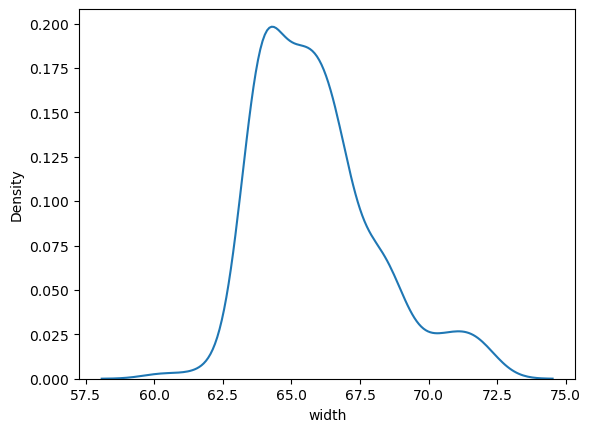

In [55]:
sns.kdeplot(df_autos['width'])

In [56]:
df_autos['width'].skew()

0.904003498786254

<Axes: >

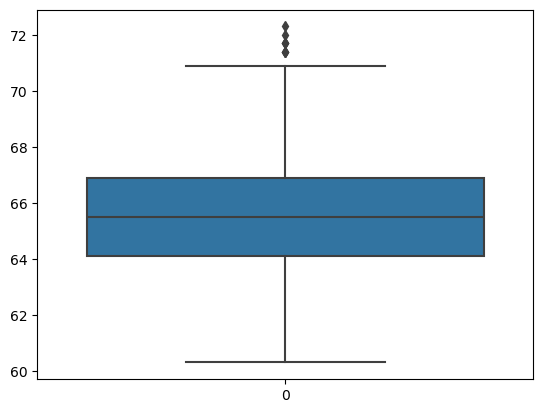

In [57]:
sns.boxplot(df_autos['width'])

In [58]:
df_autos[df_autos['width'] >= 71].shape

(8, 29)

In [59]:
df_autos['width'] = np.where(df_autos['width'] >= 71, df_autos['width'].median(), df_autos['width'])

### 3.13 Height

<Axes: xlabel='height', ylabel='Density'>

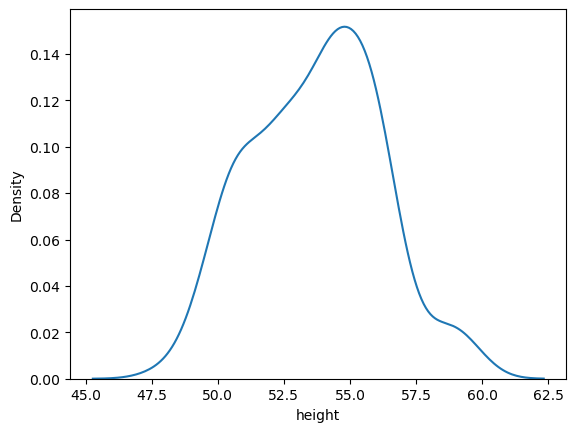

In [60]:
sns.kdeplot(df_autos['height'])

In [61]:
df_autos['height'].skew()

0.06312273247192804

### 3.14 Curb-Weight

<Axes: xlabel='curb-weight', ylabel='Density'>

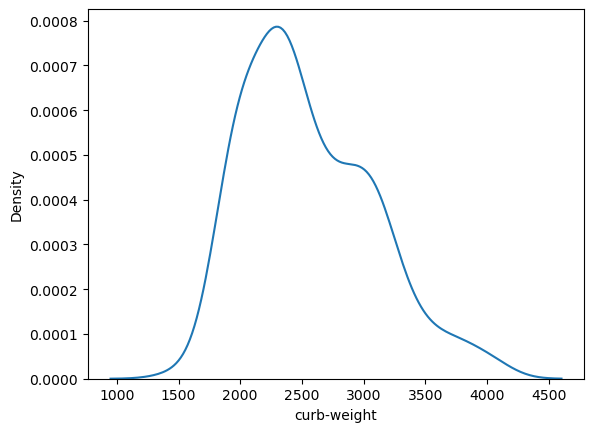

In [62]:
sns.kdeplot(df_autos['curb-weight'])

<Axes: >

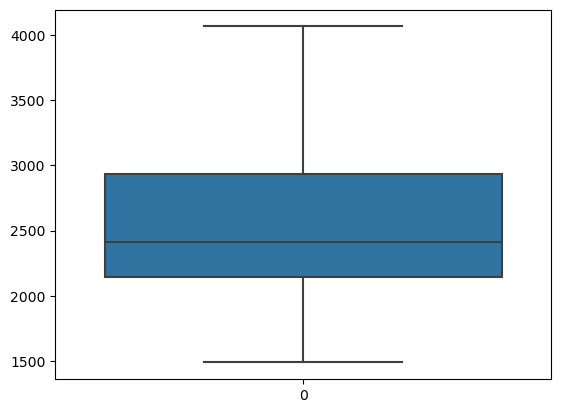

In [63]:
sns.boxplot(df_autos['curb-weight'])

## 3.15 Engine-Type

In [64]:
df_autos.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'drive-wheels', 'engine-location', 'wheel-base',
       'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'body-style_hardtop', 'body-style_hatchback',
       'body-style_sedan', 'body-style_wagon'],
      dtype='object')

In [65]:
df_autos['engine-type'].value_counts()

engine-type
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

In [66]:
engine_type_mapping = {
    'ohc': 'ohc_family',
    'ohcf': 'ohc_family',
    'ohcv': 'ohc_family',
    'dohc': 'dohc_family',
    'dohcv': 'dohc_family',
    'l': 'l',
    'rotor': 'rotary'
}
# Now apply the mapping
df_autos['engine_type_grouped'] = df_autos['engine-type'].map(engine_type_mapping)
df_autos.drop('engine-type',axis =1, inplace=True)

In [67]:
df_autos = pd.get_dummies(df_autos, columns=['engine_type_grouped'], drop_first=True, dtype=int)
df_autos

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,engine_type_grouped_l,engine_type_grouped_ohc_family,engine_type_grouped_rotary
0,3,115,alfa-romero,1,1,2,2,1,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495,0,0,0,0,0,0,0
1,3,115,alfa-romero,1,1,2,2,1,88.6,168.8,64.1,48.8,2548,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500,0,0,0,0,0,0,0
2,1,115,alfa-romero,1,1,2,2,1,94.5,171.2,65.5,52.4,2823,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500,0,1,0,0,0,1,0
3,2,164,audi,1,1,4,0,1,99.8,176.6,66.2,54.3,2337,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950,0,0,1,0,0,1,0
4,2,164,audi,1,1,4,1,1,99.4,176.6,66.4,54.3,2824,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,1,1,4,2,1,109.1,188.8,68.9,55.5,2952,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845,0,0,1,0,0,1,0
201,-1,95,volvo,1,0,4,2,1,109.1,188.8,68.8,55.5,3049,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045,0,0,1,0,0,1,0
202,-1,95,volvo,1,1,4,2,1,109.1,188.8,68.9,55.5,3012,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485,0,0,1,0,0,1,0
203,-1,95,volvo,0,0,4,2,1,109.1,188.8,68.9,55.5,3217,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470,0,0,1,0,0,1,0


### 3.16 Num-of-Cylinders

In [68]:
df_autos['num-of-cylinders'].value_counts()

num-of-cylinders
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

In [69]:
df_autos['num-of-cylinders'].value_counts().to_dict()

{'four': 159,
 'six': 24,
 'five': 11,
 'eight': 5,
 'two': 4,
 'three': 1,
 'twelve': 1}

In [70]:
df_autos.groupby('num-of-cylinders')['price'].mean().sort_values()

num-of-cylinders
three      5151.000000
four      10339.723270
two       13020.000000
five      21207.545455
six       23671.833333
eight     33761.400000
twelve    36000.000000
Name: price, dtype: float64

In [71]:
df_autos['num-of-cylinders'].replace({'four': 4,
                                         'six': 6,
                                         'five': 5,
                                         'eight': 8,
                                         'two': 2,
                                         'three': 3,
                                         'twelve': 12}, inplace=True)

### 3.17 Engine-Size

<Axes: xlabel='engine-size', ylabel='Density'>

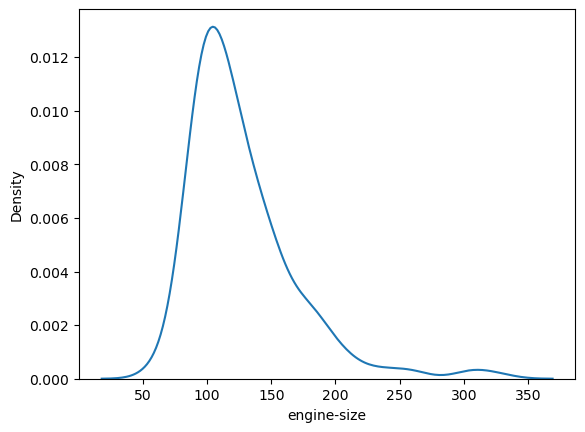

In [72]:
sns.kdeplot(df_autos['engine-size'])

<Axes: >

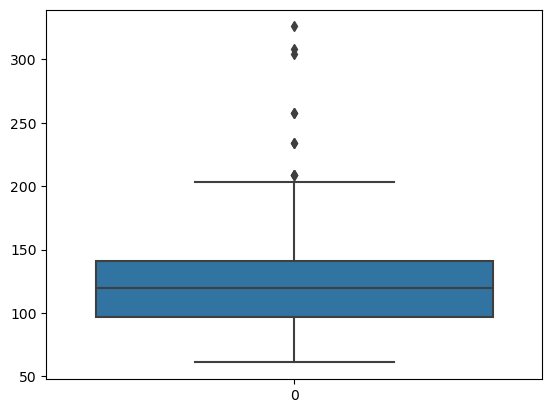

In [73]:
sns.boxplot(df_autos['engine-size'])

In [74]:
df_autos[df_autos['engine-size'] >= 200].shape

(11, 31)

In [75]:
df_autos['engine-size'] = np.where(df_autos['engine-size'] >= 200, df_autos['engine-size'].median(), df_autos['engine-size'])

### 3.18 Fuel-System

In [76]:
df_autos['fuel-system'].value_counts()

fuel-system
mpfi    94
2bbl    66
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64

In [77]:
fuel_system_mapping = {
    'mpfi': 'multi_point',
    'mfi': 'multi_point',
    'spfi': 'multi_point',
    '1bbl': 'carburetor',
    '2bbl': 'carburetor',
    '4bbl': 'carburetor',
    'idi': 'idi',
    'spdi': 'spdi'
}

df_autos['fuel_system_grouped'] = df_autos['fuel-system'].map(fuel_system_mapping)

In [78]:
df_autos = pd.get_dummies(df_autos, columns=['fuel_system_grouped'], drop_first=True,  dtype=int)
df_autos

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,engine_type_grouped_l,engine_type_grouped_ohc_family,engine_type_grouped_rotary,fuel_system_grouped_idi,fuel_system_grouped_multi_point,fuel_system_grouped_spdi
0,3,115,alfa-romero,1,1,2,2,1,88.6,168.8,64.1,48.8,2548,4,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,13495,0,0,0,0,0,0,0,0,1,0
1,3,115,alfa-romero,1,1,2,2,1,88.6,168.8,64.1,48.8,2548,4,130.0,mpfi,3.47,2.68,9.0,111,5000,21,27,16500,0,0,0,0,0,0,0,0,1,0
2,1,115,alfa-romero,1,1,2,2,1,94.5,171.2,65.5,52.4,2823,6,152.0,mpfi,2.68,3.47,9.0,154,5000,19,26,16500,0,1,0,0,0,1,0,0,1,0
3,2,164,audi,1,1,4,0,1,99.8,176.6,66.2,54.3,2337,4,109.0,mpfi,3.19,3.4,10.0,102,5500,24,30,13950,0,0,1,0,0,1,0,0,1,0
4,2,164,audi,1,1,4,1,1,99.4,176.6,66.4,54.3,2824,5,136.0,mpfi,3.19,3.4,8.0,115,5500,18,22,17450,0,0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,1,1,4,2,1,109.1,188.8,68.9,55.5,2952,4,141.0,mpfi,3.78,3.15,9.5,114,5400,23,28,16845,0,0,1,0,0,1,0,0,1,0
201,-1,95,volvo,1,0,4,2,1,109.1,188.8,68.8,55.5,3049,4,141.0,mpfi,3.78,3.15,8.7,160,5300,19,25,19045,0,0,1,0,0,1,0,0,1,0
202,-1,95,volvo,1,1,4,2,1,109.1,188.8,68.9,55.5,3012,6,173.0,mpfi,3.58,2.87,8.8,134,5500,18,23,21485,0,0,1,0,0,1,0,0,1,0
203,-1,95,volvo,0,0,4,2,1,109.1,188.8,68.9,55.5,3217,6,145.0,idi,3.01,3.4,23.0,106,4800,26,27,22470,0,0,1,0,0,1,0,1,0,0


In [79]:
df_autos.drop('fuel-system',axis = 1, inplace=True)

### 3.19 Bore

In [80]:
df_autos['bore']

0      3.47
1      3.47
2      2.68
3      3.19
4      3.19
       ... 
200    3.78
201    3.78
202    3.58
203    3.01
204    3.78
Name: bore, Length: 205, dtype: object

In [81]:
df_autos['bore'] = df_autos['bore'].astype(float)
df_autos['bore'].median()

3.31

In [82]:
df_autos['bore'].mean()

3.3297512437810943

In [83]:
df_autos['bore'].fillna(df_autos['bore'].mean(),inplace=True)

### 3.20 Stroke

In [84]:
df_autos['stroke']

0      2.68
1      2.68
2      3.47
3       3.4
4       3.4
       ... 
200    3.15
201    3.15
202    2.87
203     3.4
204    3.15
Name: stroke, Length: 205, dtype: object

In [85]:
df_autos['stroke'] = df_autos['stroke'].astype(float)
df_autos['stroke'].median()

3.29

In [86]:
df_autos[['stroke']].describe()

,stroke
count,201.000000
mean,3.255423
std,0.316717
min,2.070000
25%,3.110000
50%,3.290000
75%,3.410000
max,4.170000


In [87]:
df_autos['stroke'].fillna(df_autos['stroke'].median(),inplace=True)

### 3.21 Compression Ratio

In [88]:
df_autos['compression-ratio']

0       9.0
1       9.0
2       9.0
3      10.0
4       8.0
       ... 
200     9.5
201     8.7
202     8.8
203    23.0
204     9.5
Name: compression-ratio, Length: 205, dtype: float64

<Axes: xlabel='compression-ratio', ylabel='Density'>

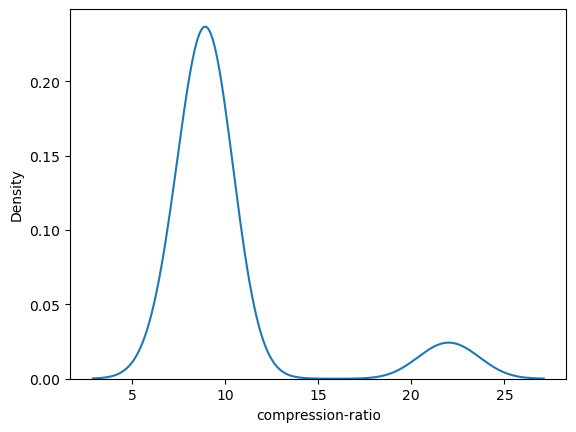

In [89]:
sns.kdeplot(df_autos['compression-ratio'])

<Axes: >

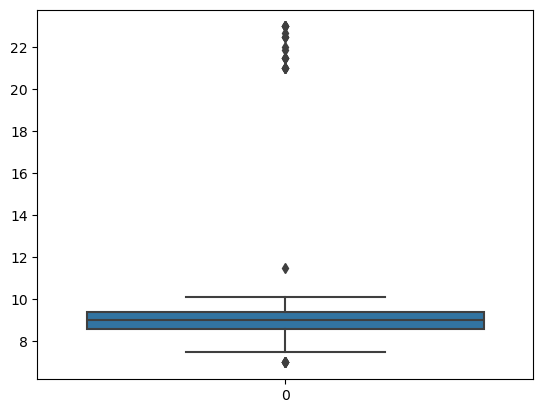

In [90]:
sns.boxplot(df_autos['compression-ratio'])

In [91]:
df_autos['compression-ratio'] = np.where(df_autos['compression-ratio'] >= 12, df_autos['compression-ratio'].median(), 
                                         df_autos['compression-ratio'])

## 3.22 horsepower

In [92]:
df_autos['horsepower'] = df_autos['horsepower'].astype(float)
df_autos['horsepower'].fillna(df_autos['horsepower'].mean(), inplace=True)
df_autos['horsepower'] = df_autos['horsepower'].astype(int)

### 3.23 Peak-RPM

In [93]:
df_autos['peak-rpm']

0      5000
1      5000
2      5000
3      5500
4      5500
       ... 
200    5400
201    5300
202    5500
203    4800
204    5400
Name: peak-rpm, Length: 205, dtype: object

In [94]:
df_autos['peak-rpm'] = df_autos['peak-rpm'].astype(float)
df_autos['peak-rpm'].fillna(df_autos['peak-rpm'].mean(), inplace=True)
df_autos['peak-rpm'] = df_autos['peak-rpm'].astype(int)

<Axes: xlabel='peak-rpm', ylabel='Density'>

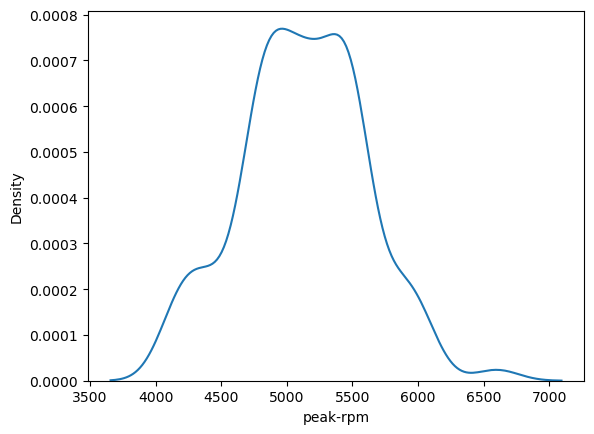

In [95]:
sns.kdeplot(df_autos['peak-rpm'])

In [96]:
df_autos['peak-rpm'].skew()

0.07361410577798844

### 3.24 City-MPG

<Axes: xlabel='city-mpg', ylabel='Density'>

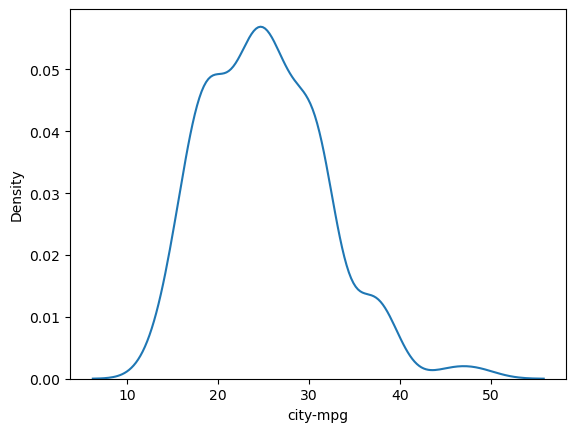

In [97]:
sns.kdeplot(df_autos['city-mpg'])

In [98]:
df_autos['city-mpg'].skew()

0.6637040288148164

<Axes: >

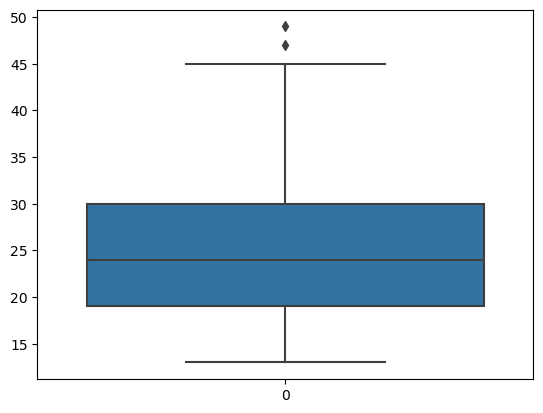

In [99]:
sns.boxplot(df_autos['city-mpg'])

In [100]:
df_autos['city-mpg'] = np.where(df_autos['city-mpg'] >= 45, df_autos['city-mpg'].median(), 
                                         df_autos['city-mpg'])

### 3.25 HIghway MPG

<Axes: xlabel='highway-mpg', ylabel='Density'>

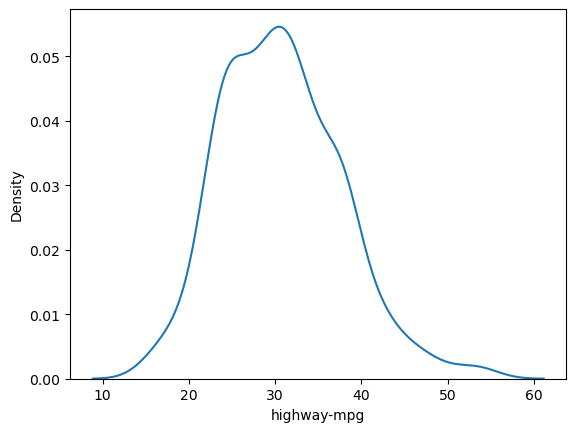

In [101]:
sns.kdeplot(df_autos['highway-mpg'])

In [102]:
df_autos['highway-mpg'].skew()

0.5399971878746754

In [103]:
df_autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   symboling                        205 non-null    int64  
 1   normalized-losses                205 non-null    int32  
 2   make                             205 non-null    object 
 3   fuel-type                        205 non-null    int64  
 4   aspiration                       205 non-null    int64  
 5   num-of-doors                     205 non-null    int32  
 6   drive-wheels                     205 non-null    int64  
 7   engine-location                  205 non-null    int64  
 8   wheel-base                       205 non-null    float64
 9   length                           205 non-null    float64
 10  width                            205 non-null    float64
 11  height                           205 non-null    float64
 12  curb-weight           

In [104]:
# df_autos[df_autos.select_dtypes(bool).columns] = df_autos.select_dtypes(bool).astype(int)
df_autos.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,engine_type_grouped_l,engine_type_grouped_ohc_family,engine_type_grouped_rotary,fuel_system_grouped_idi,fuel_system_grouped_multi_point,fuel_system_grouped_spdi
0,3,115,alfa-romero,1,1,2,2,1,88.6,168.8,64.1,48.8,2548,4,130.0,3.47,2.68,9.0,111,5000,21.0,27,13495,0,0,0,0,0,0,0,0,1,0
1,3,115,alfa-romero,1,1,2,2,1,88.6,168.8,64.1,48.8,2548,4,130.0,3.47,2.68,9.0,111,5000,21.0,27,16500,0,0,0,0,0,0,0,0,1,0
2,1,115,alfa-romero,1,1,2,2,1,94.5,171.2,65.5,52.4,2823,6,152.0,2.68,3.47,9.0,154,5000,19.0,26,16500,0,1,0,0,0,1,0,0,1,0
3,2,164,audi,1,1,4,0,1,99.8,176.6,66.2,54.3,2337,4,109.0,3.19,3.40,10.0,102,5500,24.0,30,13950,0,0,1,0,0,1,0,0,1,0
4,2,164,audi,1,1,4,1,1,99.4,176.6,66.4,54.3,2824,5,136.0,3.19,3.40,8.0,115,5500,18.0,22,17450,0,0,1,0,0,1,0,0,1,0


### 5. Feature Selection

1. Correlation:
    Cont vs Cont >> Pearson corr
    Cat vs Cat >> Chi-Square Test
    Cat vs Cont >> ANOVA    # f_classif, f_oneway, f_regression

In [107]:
df_autos.drop('make',axis=1).corr()['price'].sort_values()

highway-mpg                       -0.690526
city-mpg                          -0.680655
engine-location                   -0.331013
body-style_hatchback              -0.289594
aspiration                        -0.177285
compression-ratio                 -0.166876
engine_type_grouped_ohc_family    -0.134111
fuel-type                         -0.110207
peak-rpm                          -0.100851
symboling                         -0.080137
fuel_system_grouped_spdi          -0.060513
body-style_wagon                  -0.039652
engine_type_grouped_rotary        -0.003363
num-of-doors                       0.041945
engine_type_grouped_l              0.045123
stroke                             0.082034
normalized-losses                  0.094337
fuel_system_grouped_idi            0.110207
height                             0.134388
body-style_sedan                   0.146641
body-style_hardtop                 0.231087
fuel_system_grouped_multi_point    0.500915
wheel-base                      

In [121]:
fs1 = pd.DataFrame(df_autos.drop('make',axis=1).corr()['price'].sort_values().reset_index())
fs1[fs1['price'].between(-0.2, 0.2)]['index'].values
# fs1

array(['aspiration', 'compression-ratio',
       'engine_type_grouped_ohc_family', 'fuel-type', 'peak-rpm',
       'symboling', 'fuel_system_grouped_spdi', 'body-style_wagon',
       'engine_type_grouped_rotary', 'num-of-doors',
       'engine_type_grouped_l', 'stroke', 'normalized-losses',
       'fuel_system_grouped_idi', 'height', 'body-style_sedan'],
      dtype=object)

In [117]:
df_autos.drop('make',axis=1).corr()['price']#.head(22).sort_values().head(4).index

Index(['highway-mpg', 'city-mpg', 'engine-location', 'aspiration'], dtype='object')

In [118]:
df_autos.drop('make',axis=1).corr()['price'].head(22).sort_values().tail(9).index

Index(['bore', 'engine-size', 'width', 'drive-wheels', 'length',
       'num-of-cylinders', 'horsepower', 'curb-weight', 'price'],
      dtype='object')

In [119]:
df_autos.drop('make',axis=1).corr()['price'].head(22).sort_values()[4:-9].index

Index(['compression-ratio', 'fuel-type', 'peak-rpm', 'symboling',
       'num-of-doors', 'stroke', 'normalized-losses', 'height', 'wheel-base'],
      dtype='object')

In [122]:
df_autos.shape

(205, 33)

## 6. Model Training

### Train Test Split

In [156]:
# x = df_autos.drop(['aspiration', 'compression-ratio',
#        'engine_type_grouped_ohc_family', 'fuel-type', 'peak-rpm',
#        'symboling', 'fuel_system_grouped_spdi', 'body-style_wagon',
#        'engine_type_grouped_rotary', 'num-of-doors',
#        'engine_type_grouped_l', 'stroke', 'normalized-losses',
#        'fuel_system_grouped_idi', 'height', 'body-style_sedan','make','price'], axis = 1)

x = df_autos.drop(['make','price'], axis = 1)

y = df_autos['price']
x.shape

(205, 31)

In [157]:
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.2, random_state=2)

In [158]:
def model_building(algo, x , y):
    model = algo
    model.fit(x,y)
    return model

linear_reg = model_building(LinearRegression(), x_train, y_train)
linear_reg

LinearRegression()

## 7. Evaluation

In [159]:
y_pred = linear_reg.predict(x_test)
y_pred[:5]

array([ 5742.87524245, 13302.48837703,  9684.14977212, 15977.31462778,
       16143.57350628])

In [160]:
y_test[:5]

25      6692
84     14489
100     9549
10     16430
195    13415
Name: price, dtype: int32

In [161]:
def evaluation(string, model, ind_var, y_act):
    print(string.center(50,'*'))
    pred = model.predict(ind_var)
    
    mse = mean_squared_error(y_act, pred)
    print('MSE :', mse)
    
    rmse = np.sqrt(mse)
    print('RMSE :', rmse)
    
    mae = mean_absolute_error(y_act, pred)
    print('MAE :', mae)
    
    r_squared = r2_score(y_act, pred)
    print('R2_score:', r_squared)
    
    adj_r2 = 1 - (((1-r_squared)*(ind_var.shape[0] - 1))/(ind_var.shape[0]-ind_var.shape[1]-1))
    print('Adjusted R2 :', adj_r2)
    
evaluation('Test Data Evaluation', linear_reg, x_test, y_test)
print()

evaluation('Train Data Evaluation', linear_reg, x_train, y_train)

***************Test Data Evaluation***************
MSE : 15942392.96966769
RMSE : 3992.7926279319454
MAE : 2781.4946594143516
R2_score: 0.5380416147225351
Adjusted R2 : -1.0531483790109553

**************Train Data Evaluation***************
MSE : 6868727.0698874155
RMSE : 2620.825646602119
MAE : 1912.6824485677726
R2_score: 0.8995507380886242
Adjusted R2 : 0.875960381124589


## Ridge Regression

In [162]:
ridge_model = model_building(Ridge(alpha=0.5), x_train, y_train)
ridge_model

Ridge(alpha=0.5)

In [163]:
evaluation('Test Data Evaluation', ridge_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', ridge_model, x_train, y_train)

***************Test Data Evaluation***************
MSE : 14717286.67361301
RMSE : 3836.3115975651676
MAE : 2645.2697977959974
R2_score: 0.5735411866748423
Adjusted R2 : -0.8953725036673674

**************Train Data Evaluation***************
MSE : 7243067.919377356
RMSE : 2691.294840662642
MAE : 1948.4982424768423
R2_score: 0.8940763231567235
Adjusted R2 : 0.8692003081404994


## Lasso Regression

In [164]:
lasso_model = model_building(Lasso(alpha=5), x_train, y_train)
lasso_model

Lasso(alpha=5)

In [165]:
evaluation('Test Data Evaluation', lasso_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', lasso_model, x_train, y_train)

***************Test Data Evaluation***************
MSE : 15053545.655636223
RMSE : 3879.8899025147894
MAE : 2633.7848193762375
R2_score: 0.5637975016040983
Adjusted R2 : -0.9386777706484521

**************Train Data Evaluation***************
MSE : 6915130.127806474
RMSE : 2629.663500869736
MAE : 1901.7513251835096
R2_score: 0.8988721330325528
Adjusted R2 : 0.8751224066992886


In [166]:
linear_reg.coef_

array([ 4.72217956e+02,  4.65615952e+00, -6.54906909e+02, -1.51294662e+03,
       -2.69870727e+02,  9.27147305e+02, -2.07928908e+04,  1.23921325e+02,
        1.35805860e+02,  2.39455924e+02,  8.51251011e+01,  9.05569500e+00,
        2.49896899e+03, -8.48448331e+01,  3.34481357e+03,  1.18854007e+03,
       -1.38923849e+03, -3.67870455e+01,  2.25839056e+00, -9.25113039e+01,
        8.74718545e+01, -3.42051749e+03, -4.82619456e+03, -4.65870360e+03,
       -6.74526337e+03, -4.89193215e+03,  2.19324947e+03,  3.02863766e+03,
        6.54906909e+02, -6.29744294e+02, -3.07879265e+03])

In [167]:
ridge_model.coef_

array([ 7.15120678e+02, -3.98902428e+00, -1.08735956e+03, -5.57900569e+02,
       -2.64787472e+02,  1.03519535e+03, -1.42848569e+04,  1.11706668e+02,
        1.26499991e+02,  1.74279299e+02,  5.68173850e+01,  9.09359567e+00,
        2.08409721e+03, -7.37241074e+01,  1.84601969e+03,  2.71924480e+02,
       -1.36224559e+03, -1.48944028e+01,  2.40580609e+00, -1.00440602e+02,
        7.47936614e+01, -1.48425015e+03, -3.60597395e+03, -3.09002171e+03,
       -5.13610736e+03, -3.40040948e+03,  2.67120568e+03,  1.69008189e+03,
        1.08735956e+03, -9.00248483e+02, -2.95166958e+03])

In [168]:
lasso_model.coef_

array([ 5.42225934e+02,  2.08792062e+00, -1.51383116e+03, -1.02455705e+03,
       -2.98452308e+02,  9.28421733e+02, -2.03076381e+04,  1.21397086e+02,
        1.31374545e+02,  2.41528341e+02,  5.47523099e+01,  9.50802128e+00,
        2.17946842e+03, -8.45390244e+01,  2.19957567e+03,  6.20398566e+02,
       -1.31439457e+03, -2.91517688e+01,  2.09294240e+00, -9.67100045e+01,
        7.13633006e+01, -2.14982231e+03, -3.76361745e+03, -3.47052328e+03,
       -5.57857943e+03, -4.59264823e+03,  2.21248020e+03,  1.69096093e+03,
        1.07811736e+02, -6.44233059e+02, -2.81668256e+03])

In [169]:
pd.Series(ridge_model.coef_, index = x.columns)

symboling                            715.120678
normalized-losses                     -3.989024
fuel-type                          -1087.359562
aspiration                          -557.900569
num-of-doors                        -264.787472
drive-wheels                        1035.195348
engine-location                   -14284.856933
wheel-base                           111.706668
length                               126.499991
width                                174.279299
height                                56.817385
curb-weight                            9.093596
num-of-cylinders                    2084.097214
engine-size                          -73.724107
bore                                1846.019692
stroke                               271.924480
compression-ratio                  -1362.245592
horsepower                           -14.894403
peak-rpm                               2.405806
city-mpg                            -100.440602
highway-mpg                           74

<Axes: >

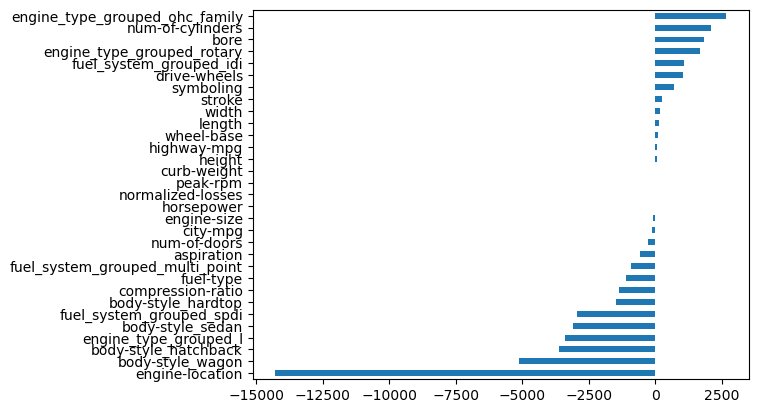

In [170]:
rm_feat = pd.Series(ridge_model.coef_, index=x.columns)
rm_feat.sort_values().plot(kind = 'barh')

<Axes: >

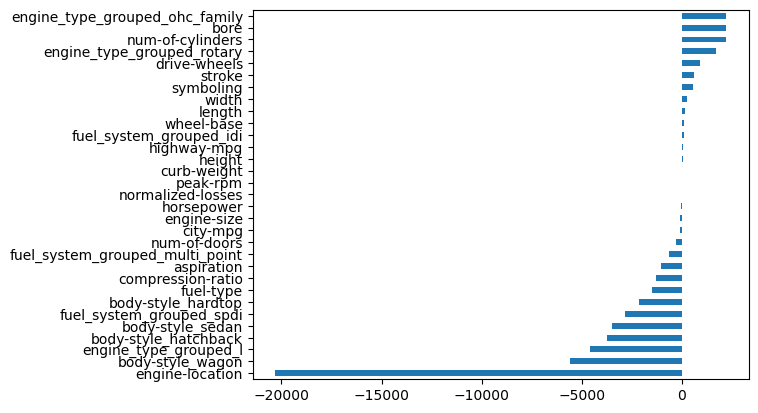

In [171]:
ls_feat = pd.Series(lasso_model.coef_, index=x.columns)
ls_feat.sort_values().plot(kind = 'barh')

In [172]:
ls_feat.sort_values()

engine-location                   -20307.638074
body-style_wagon                   -5578.579426
engine_type_grouped_l              -4592.648234
body-style_hatchback               -3763.617450
body-style_sedan                   -3470.523277
fuel_system_grouped_spdi           -2816.682561
body-style_hardtop                 -2149.822309
fuel-type                          -1513.831160
compression-ratio                  -1314.394568
aspiration                         -1024.557046
fuel_system_grouped_multi_point     -644.233059
num-of-doors                        -298.452308
city-mpg                             -96.710005
engine-size                          -84.539024
horsepower                           -29.151769
normalized-losses                      2.087921
peak-rpm                               2.092942
curb-weight                            9.508021
height                                54.752310
highway-mpg                           71.363301
fuel_system_grouped_idi              107

In [173]:
df1 = ls_feat.reset_index()
df1.columns = ['Features','Coeff']
df1

,Features,Coeff
0,symboling,542.225934
1,normalized-losses,2.087921
2,fuel-type,-1513.831160
3,aspiration,-1024.557046
4,num-of-doors,-298.452308
5,drive-wheels,928.421733
6,engine-location,-20307.638074
7,wheel-base,121.397086
8,length,131.374545
9,width,241.528341


In [175]:
rm_feat = df1[df1['Coeff'].between(-650,650)]['Features'].values
rm_feat

array(['symboling', 'normalized-losses', 'num-of-doors', 'wheel-base',
       'length', 'width', 'height', 'curb-weight', 'engine-size',
       'stroke', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg',
       'fuel_system_grouped_idi', 'fuel_system_grouped_multi_point'],
      dtype=object)

In [176]:
x = df_autos.drop(['symboling', 'normalized-losses', 'num-of-doors', 'wheel-base',
       'length', 'width', 'height', 'curb-weight', 'engine-size',
       'stroke', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg',
       'fuel_system_grouped_idi', 'fuel_system_grouped_multi_point', 'make', 'price'], axis = 1)

y = df_autos['price']

In [177]:
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.2, random_state=2)

In [180]:
lasso_model = model_building(Lasso(alpha=5), x_train, y_train)
lasso_model

Lasso(alpha=5)

In [181]:
evaluation('Test Data Evaluation', lasso_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', lasso_model, x_train, y_train)

***************Test Data Evaluation***************
MSE : 13098841.118554104
RMSE : 3619.2321172527886
MAE : 2513.123478216277
R2_score: 0.6204384433600216
Adjusted R2 : 0.39270150937603465

**************Train Data Evaluation***************
MSE : 14065109.594556592
RMSE : 3750.347929800193
MAE : 2714.7756140699457
R2_score: 0.7943097952356145
Adjusted R2 : 0.7734628150230078


In [184]:
ridge_model = model_building(Ridge(alpha=0.5), x_train, y_train)
ridge_model

Ridge(alpha=0.5)

In [185]:
evaluation('Test Data Evaluation', ridge_model, x_test, y_test)
print()

evaluation('Train Data Evaluation', ridge_model, x_train, y_train)

***************Test Data Evaluation***************
MSE : 12811198.646180272
RMSE : 3579.2734802163795
MAE : 2545.507079410629
R2_score: 0.6287733810527414
Adjusted R2 : 0.4060374096843862

**************Train Data Evaluation***************
MSE : 14195823.338897996
RMSE : 3767.7345101397464
MAE : 2706.4947993332275
R2_score: 0.7923982184605918
Adjusted R2 : 0.7713574973586248


In [186]:
models = [ ('Linear Regression', LinearRegression()), ('Lasso', Lasso(alpha=10)), ('Ridge',Ridge(alpha=5))]

for name, model in models:
    print(name)
    new_model = model_building(model, x_train, y_train)
    evaluation('Test Data Evaluation', new_model, x_test, y_test)
    print()

    evaluation('Train Data Evaluation', new_model, x_train, y_train)
    
    print('**'*25)

Linear Regression
***************Test Data Evaluation***************
MSE : 13367595.22905621
RMSE : 3656.1722099835793
MAE : 2522.8805443417245
R2_score: 0.6126508285922481
Adjusted R2 : 0.38024132574759695

**************Train Data Evaluation***************
MSE : 14044392.468250118
RMSE : 3747.5848847291127
MAE : 2716.2822829424085
R2_score: 0.7946127654985521
Adjusted R2 : 0.7737964917315134
**************************************************
Lasso
***************Test Data Evaluation***************
MSE : 12855547.83816724
RMSE : 3585.4634063349804
MAE : 2504.1719799013026
R2_score: 0.6274882865780511
Adjusted R2 : 0.40398125852488176

**************Train Data Evaluation***************
MSE : 14120049.779909454
RMSE : 3757.6654693984474
MAE : 2719.665685850104
R2_score: 0.7935063419884818
Adjusted R2 : 0.7725779307035306
**************************************************
Ridge
***************Test Data Evaluation***************
MSE : 12199651.120319434
RMSE : 3492.799896976555
MAE : 2623

In [187]:
def evaluation(string, model, ind_var, y_act):
    print(string.center(50,'*'))
    pred = model.predict(ind_var)
    
    mse = mean_squared_error(y_act, pred)
    print('MSE :', mse)
    
    rmse = np.sqrt(mse)
    print('RMSE :', rmse)
    
    mae = mean_absolute_error(y_act, pred)
    print('MAE :', mae)
    
    r_squared = r2_score(y_act, pred)
    print('R2_score:', r_squared)
    
    adj_r2 = 1 - (((1-r_squared)*(ind_var.shape[0] - 1))/(ind_var.shape[0]-ind_var.shape[1]-1))
    print('Adjusted R2 :', adj_r2)
    
    return mse, rmse, mae, r_squared, adj_r2
    
mse, rmse, mae, r_squared, adj_r2 = evaluation('Test Data Evaluation', lasso_model, x_test, y_test)
# print()

# evaluation('Train Data Evaluation', linear_reg, x_train, y_train)

***************Test Data Evaluation***************
MSE : 13098841.118554104
RMSE : 3619.2321172527886
MAE : 2513.123478216277
R2_score: 0.6204384433600216
Adjusted R2 : 0.39270150937603465


In [188]:
models = [ ('Linear Regression', LinearRegression()), ('Lasso', Lasso(alpha=10)), ('Ridge',Ridge(alpha=5))]

model_report  = {}

for name, model in models:
    print(name)
    test1 = {}
    
    new_model = model_building(model, x_train, y_train)
    mse, rmse, mae, r_squared, adj_r2 = evaluation('Test Data Evaluation', new_model, x_test, y_test)
    test1['Testing Evaluation'] = [mse, rmse, mae, r_squared, adj_r2]
    
    model_report[name] = test1
    
    train1 = {}
    
    mse, rmse, mae, r_squared, adj_r2 = evaluation('Train Data Evaluation', new_model, x_train, y_train)
    train1['Training Evaluation'] = [mse, rmse, mae, r_squared, adj_r2]
    
    model_report[name].update(train1)

Linear Regression
***************Test Data Evaluation***************
MSE : 13367595.22905621
RMSE : 3656.1722099835793
MAE : 2522.8805443417245
R2_score: 0.6126508285922481
Adjusted R2 : 0.38024132574759695
**************Train Data Evaluation***************
MSE : 14044392.468250118
RMSE : 3747.5848847291127
MAE : 2716.2822829424085
R2_score: 0.7946127654985521
Adjusted R2 : 0.7737964917315134
Lasso
***************Test Data Evaluation***************
MSE : 12855547.83816724
RMSE : 3585.4634063349804
MAE : 2504.1719799013026
R2_score: 0.6274882865780511
Adjusted R2 : 0.40398125852488176
**************Train Data Evaluation***************
MSE : 14120049.779909454
RMSE : 3757.6654693984474
MAE : 2719.665685850104
R2_score: 0.7935063419884818
Adjusted R2 : 0.7725779307035306
Ridge
***************Test Data Evaluation***************
MSE : 12199651.120319434
RMSE : 3492.799896976555
MAE : 2623.306861599921
R2_score: 0.6464940273888724
Adjusted R2 : 0.4343904438221958
**************Train Data Eva

In [189]:
model_report

{'Linear Regression': {'Testing Evaluation': [13367595.22905621,
   3656.1722099835793,
   2522.8805443417245,
   0.6126508285922481,
   0.38024132574759695],
  'Training Evaluation': [14044392.468250118,
   3747.5848847291127,
   2716.2822829424085,
   0.7946127654985521,
   0.7737964917315134]},
 'Lasso': {'Testing Evaluation': [12855547.83816724,
   3585.4634063349804,
   2504.1719799013026,
   0.6274882865780511,
   0.40398125852488176],
  'Training Evaluation': [14120049.779909454,
   3757.6654693984474,
   2719.665685850104,
   0.7935063419884818,
   0.7725779307035306]},
 'Ridge': {'Testing Evaluation': [12199651.120319434,
   3492.799896976555,
   2623.306861599921,
   0.6464940273888724,
   0.4343904438221958],
  'Training Evaluation': [16271750.173072223,
   4033.8257489723355,
   2863.765436024663,
   0.7620395630426182,
   0.7379219511888295]}}

In [190]:
pd.DataFrame(model_report).stack()

Testing Evaluation   Linear Regression    [13367595.22905621, 3656.1722099835793, 2522.8...
                     Lasso                [12855547.83816724, 3585.4634063349804, 2504.1...
                     Ridge                [12199651.120319434, 3492.799896976555, 2623.3...
Training Evaluation  Linear Regression    [14044392.468250118, 3747.5848847291127, 2716....
                     Lasso                [14120049.779909454, 3757.6654693984474, 2719....
                     Ridge                [16271750.173072223, 4033.8257489723355, 2863....
dtype: object

In [191]:
pd.DataFrame(model_report).unstack()

Linear Regression  Testing Evaluation     [13367595.22905621, 3656.1722099835793, 2522.8...
                   Training Evaluation    [14044392.468250118, 3747.5848847291127, 2716....
Lasso              Testing Evaluation     [12855547.83816724, 3585.4634063349804, 2504.1...
                   Training Evaluation    [14120049.779909454, 3757.6654693984474, 2719....
Ridge              Testing Evaluation     [12199651.120319434, 3492.799896976555, 2623.3...
                   Training Evaluation    [16271750.173072223, 4033.8257489723355, 2863....
dtype: object

In [192]:
df3 = pd.DataFrame(model_report)
pd.DataFrame(df3.unstack()).T

Linear Regression  \
                                  Testing Evaluation   
0  [13367595.22905621, 3656.1722099835793, 2522.8...   

                                                      \
                                 Training Evaluation   
0  [14044392.468250118, 3747.5848847291127, 2716....   

                                               Lasso  \
                                  Testing Evaluation   
0  [12855547.83816724, 3585.4634063349804, 2504.1...   

                                                      \
                                 Training Evaluation   
0  [14120049.779909454, 3757.6654693984474, 2719....   

                                               Ridge  \
                                  Testing Evaluation   
0  [12199651.120319434, 3492.799896976555, 2623.3...   

                                                      
                                 Training Evaluation  
0  [16271750.173072223, 4033.8257489723355, 2863....

In [193]:
reformed_dict = {}

for outerkey, innerdict in model_report.items():
    for innerkey, values in innerdict.items():
        reformed_dict[(outerkey,innerkey)] = values
        
# FInal Output
final_df = pd.DataFrame(reformed_dict)
final_df.index = ['MSE','RMSE','MAE','R2_Score','ADJ_R2_Score']
final_df = np.around(final_df,2)
final_df

Linear Regression                                  Lasso  \
             Testing Evaluation Training Evaluation Testing Evaluation   
MSE                 13367595.23         14044392.47        12855547.84   
RMSE                    3656.17             3747.58            3585.46   
MAE                     2522.88             2716.28            2504.17   
R2_Score                   0.61                0.79               0.63   
ADJ_R2_Score               0.38                0.77               0.40   

                                              Ridge                      
             Training Evaluation Testing Evaluation Training Evaluation  
MSE                  14120049.78        12199651.12         16271750.17  
RMSE                     3757.67            3492.80             4033.83  
MAE                      2719.67            2623.31             2863.77  
R2_Score                    0.79               0.65                0.76  
ADJ_R2_Score                0.77               0.43                0.74

In [194]:
final_df.to_csv('Model_report.csv')

## Cross Validation

In [195]:
k_folds = KFold(n_splits=5)

scores = cross_val_score(ridge_model, x_train, y_train, cv= k_folds)

print('Cross Valisations Score:', scores)
print('Average CV Scores :', scores.mean())

Cross Valisations Score: [0.74150776 0.70770501 0.67349536 0.75968749 0.66326217]
Average CV Scores : 0.7091315564290077


In [196]:
k_folds = KFold(n_splits=5)

scores = cross_val_score(ridge_model, x_test, y_test, cv= k_folds)

print('Cross Valisations Score:', scores)
print('Average CV Scores :', scores.mean())

Cross Valisations Score: [0.60071347 0.13744416 0.55028327 0.06850288 0.26868038]
Average CV Scores : 0.3251248337888418


In [197]:
class AutosData():
    
    def __init__(self, x_train,x_test, y_train, y_test):
        self.x_train = x_train
        self.x_test = x_test
        self.y_train = y_train
        self.y_test = y_test
        
    def Linear_Regression(self, algo):
        model = model_building(algo, self.x_train, self.y_train)
        return model
    
    def evaluation_metric(self,string, model, ind_var, y_act):
        mse, rmse, mae, r_squared, adj_r2 = evaluation(string, new_model, x_train, y_train)
        return mse, rmse, mae, r_squared, adj_r2
        
data_model = AutosData(x_train,x_test, y_train, y_test)
lr_model = data_model.Linear_Regression(LinearRegression())
mse, rmse, mae, r_squared, adj_r2 = data_model.evaluation_metric('Test Data Evaluation',lr_model, x_test, y_test)

***************Test Data Evaluation***************
MSE : 16271750.173072223
RMSE : 4033.8257489723355
MAE : 2863.765436024663
R2_score: 0.7620395630426182
Adjusted R2 : 0.7379219511888295


## Hyperparameters Tuning

In [198]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

- To Optimise Overfitting and Underfitting Problem
- To find the best parameters for Machine Learning Models

1. GridSearchCV
2. RandomizedSearchCV

In [200]:
a1 = np.arange(0.01, 1, 0.02)
a2 = np.arange(1, 20, 0.2)
alpha_array = np.append(a1,a2)
print(len(alpha_array), alpha_array)

145 [1.00e-02 3.00e-02 5.00e-02 7.00e-02 9.00e-02 1.10e-01 1.30e-01 1.50e-01
 1.70e-01 1.90e-01 2.10e-01 2.30e-01 2.50e-01 2.70e-01 2.90e-01 3.10e-01
 3.30e-01 3.50e-01 3.70e-01 3.90e-01 4.10e-01 4.30e-01 4.50e-01 4.70e-01
 4.90e-01 5.10e-01 5.30e-01 5.50e-01 5.70e-01 5.90e-01 6.10e-01 6.30e-01
 6.50e-01 6.70e-01 6.90e-01 7.10e-01 7.30e-01 7.50e-01 7.70e-01 7.90e-01
 8.10e-01 8.30e-01 8.50e-01 8.70e-01 8.90e-01 9.10e-01 9.30e-01 9.50e-01
 9.70e-01 9.90e-01 1.00e+00 1.20e+00 1.40e+00 1.60e+00 1.80e+00 2.00e+00
 2.20e+00 2.40e+00 2.60e+00 2.80e+00 3.00e+00 3.20e+00 3.40e+00 3.60e+00
 3.80e+00 4.00e+00 4.20e+00 4.40e+00 4.60e+00 4.80e+00 5.00e+00 5.20e+00
 5.40e+00 5.60e+00 5.80e+00 6.00e+00 6.20e+00 6.40e+00 6.60e+00 6.80e+00
 7.00e+00 7.20e+00 7.40e+00 7.60e+00 7.80e+00 8.00e+00 8.20e+00 8.40e+00
 8.60e+00 8.80e+00 9.00e+00 9.20e+00 9.40e+00 9.60e+00 9.80e+00 1.00e+01
 1.02e+01 1.04e+01 1.06e+01 1.08e+01 1.10e+01 1.12e+01 1.14e+01 1.16e+01
 1.18e+01 1.20e+01 1.22e+01 1.24e+01 1.26e+01 1

## GridSearchCV

#### Ridge

In [201]:
ridge_model = Ridge(alpha=1)

hyperparameters = {'alpha': alpha_array}

gscv_ridge_model = GridSearchCV(ridge_model, hyperparameters, cv= 3)
gscv_ridge_model.fit(x_train, y_train)
gscv_ridge_model

GridSearchCV(cv=3, estimator=Ridge(alpha=1),
             param_grid={'alpha': array([1.00e-02, 3.00e-02, 5.00e-02, 7.00e-02, 9.00e-02, 1.10e-01,
       1.30e-01, 1.50e-01, 1.70e-01, 1.90e-01, 2.10e-01, 2.30e-01,
       2.50e-01, 2.70e-01, 2.90e-01, 3.10e-01, 3.30e-01, 3.50e-01,
       3.70e-01, 3.90e-01, 4.10e-01, 4.30e-01, 4.50e-01, 4.70e-01,
       4.90e-01, 5.10e-01, 5.30e-01, 5.50e-01, 5.70e-01, 5.90e-01,
       6.10e-01, 6...
       1.14e+01, 1.16e+01, 1.18e+01, 1.20e+01, 1.22e+01, 1.24e+01,
       1.26e+01, 1.28e+01, 1.30e+01, 1.32e+01, 1.34e+01, 1.36e+01,
       1.38e+01, 1.40e+01, 1.42e+01, 1.44e+01, 1.46e+01, 1.48e+01,
       1.50e+01, 1.52e+01, 1.54e+01, 1.56e+01, 1.58e+01, 1.60e+01,
       1.62e+01, 1.64e+01, 1.66e+01, 1.68e+01, 1.70e+01, 1.72e+01,
       1.74e+01, 1.76e+01, 1.78e+01, 1.80e+01, 1.82e+01, 1.84e+01,
       1.86e+01, 1.88e+01, 1.90e+01, 1.92e+01, 1.94e+01, 1.96e+01,
       1.98e+01])})

In [202]:
gscv_ridge_model.best_estimator_

Ridge(alpha=0.24999999999999997)

In [203]:
gscv_ridge_model.best_params_

{'alpha': 0.24999999999999997}

In [ ]:
# ridge_model = gscv_ridge_model.best_estimator_
# ridge_model = Ridge(alpha=2)
# evaluation('Test Data Evaluation', gscv_ridge_model.best_estimator_, x_test, y_test)
# print()

# evaluation('Train Data Evaluation', gscv_ridge_model.best_estimator_, x_train, y_train)

In [204]:
evaluation('Test Data Evaluation', gscv_ridge_model.best_estimator_, x_test, y_test)
print()

evaluation('Train Data Evaluation', gscv_ridge_model.best_estimator_, x_train, y_train)

***************Test Data Evaluation***************
MSE : 13038126.36658706
RMSE : 3610.834580341096
MAE : 2532.735960546083
R2_score: 0.6221977582153624
Adjusted R2 : 0.39551641314457986

**************Train Data Evaluation***************
MSE : 14090978.85611149
RMSE : 3753.795260281451
MAE : 2703.654469323715
R2_score: 0.7939314793987874
Adjusted R2 : 0.7730461563648807


(14090978.85611149,
 3753.795260281451,
 2703.654469323715,
 0.7939314793987874,
 0.7730461563648807)

#### Lasso

In [205]:
lasso_model = Lasso(alpha=1)

hyperparameters = {'alpha': alpha_array}

gscv_lasso_model = GridSearchCV(lasso_model, hyperparameters, cv= 3)
gscv_lasso_model.fit(x_train, y_train)
gscv_lasso_model

GridSearchCV(cv=3, estimator=Lasso(alpha=1),
             param_grid={'alpha': array([1.00e-02, 3.00e-02, 5.00e-02, 7.00e-02, 9.00e-02, 1.10e-01,
       1.30e-01, 1.50e-01, 1.70e-01, 1.90e-01, 2.10e-01, 2.30e-01,
       2.50e-01, 2.70e-01, 2.90e-01, 3.10e-01, 3.30e-01, 3.50e-01,
       3.70e-01, 3.90e-01, 4.10e-01, 4.30e-01, 4.50e-01, 4.70e-01,
       4.90e-01, 5.10e-01, 5.30e-01, 5.50e-01, 5.70e-01, 5.90e-01,
       6.10e-01, 6...
       1.14e+01, 1.16e+01, 1.18e+01, 1.20e+01, 1.22e+01, 1.24e+01,
       1.26e+01, 1.28e+01, 1.30e+01, 1.32e+01, 1.34e+01, 1.36e+01,
       1.38e+01, 1.40e+01, 1.42e+01, 1.44e+01, 1.46e+01, 1.48e+01,
       1.50e+01, 1.52e+01, 1.54e+01, 1.56e+01, 1.58e+01, 1.60e+01,
       1.62e+01, 1.64e+01, 1.66e+01, 1.68e+01, 1.70e+01, 1.72e+01,
       1.74e+01, 1.76e+01, 1.78e+01, 1.80e+01, 1.82e+01, 1.84e+01,
       1.86e+01, 1.88e+01, 1.90e+01, 1.92e+01, 1.94e+01, 1.96e+01,
       1.98e+01])})

In [206]:
gscv_lasso_model.best_estimator_

Lasso(alpha=19.799999999999997)

In [207]:
gscv_lasso_model.best_params_

{'alpha': 19.799999999999997}

In [208]:
evaluation('Test Data Evaluation', gscv_lasso_model.best_estimator_, x_test, y_test)
print()

evaluation('Train Data Evaluation', gscv_lasso_model.best_estimator_, x_train, y_train)

***************Test Data Evaluation***************
MSE : 12358485.650743218
RMSE : 3515.4637888539287
MAE : 2501.8536677373277
R2_score: 0.6418915223985311
Adjusted R2 : 0.42702643583764976

**************Train Data Evaluation***************
MSE : 14220618.791203622
RMSE : 3771.0235734086336
MAE : 2713.351674229127
R2_score: 0.7920356061661278
Adjusted R2 : 0.7709581338181002


(14220618.791203622,
 3771.0235734086336,
 2713.351674229127,
 0.7920356061661278,
 0.7709581338181002)

## RandomizedSearchCV

In [209]:
len(alpha_array)//2

72

In [210]:
lasso_model = Lasso(alpha=1)

hyperparameters = {'alpha': alpha_array}

rscv_lasso_model = RandomizedSearchCV(lasso_model, hyperparameters, cv= 5, n_iter=len(alpha_array)//2)
rscv_lasso_model.fit(x_train, y_train)
rscv_lasso_model

RandomizedSearchCV(cv=5, estimator=Lasso(alpha=1), n_iter=72,
                   param_distributions={'alpha': array([1.00e-02, 3.00e-02, 5.00e-02, 7.00e-02, 9.00e-02, 1.10e-01,
       1.30e-01, 1.50e-01, 1.70e-01, 1.90e-01, 2.10e-01, 2.30e-01,
       2.50e-01, 2.70e-01, 2.90e-01, 3.10e-01, 3.30e-01, 3.50e-01,
       3.70e-01, 3.90e-01, 4.10e-01, 4.30e-01, 4.50e-01, 4.70e-01,
       4.90e-01, 5.10e-01, 5.30e-01, 5.50e-01, 5.7...
       1.14e+01, 1.16e+01, 1.18e+01, 1.20e+01, 1.22e+01, 1.24e+01,
       1.26e+01, 1.28e+01, 1.30e+01, 1.32e+01, 1.34e+01, 1.36e+01,
       1.38e+01, 1.40e+01, 1.42e+01, 1.44e+01, 1.46e+01, 1.48e+01,
       1.50e+01, 1.52e+01, 1.54e+01, 1.56e+01, 1.58e+01, 1.60e+01,
       1.62e+01, 1.64e+01, 1.66e+01, 1.68e+01, 1.70e+01, 1.72e+01,
       1.74e+01, 1.76e+01, 1.78e+01, 1.80e+01, 1.82e+01, 1.84e+01,
       1.86e+01, 1.88e+01, 1.90e+01, 1.92e+01, 1.94e+01, 1.96e+01,
       1.98e+01])})

In [211]:
rscv_lasso_model.best_estimator_

Lasso(alpha=19.799999999999997)

In [212]:
rscv_lasso_model.best_params_

{'alpha': 19.799999999999997}

In [213]:
evaluation('Test Data Evaluation', rscv_lasso_model.best_estimator_, x_test, y_test)
print()

evaluation('Train Data Evaluation', rscv_lasso_model.best_estimator_, x_train, y_train)

***************Test Data Evaluation***************
MSE : 12358485.650743218
RMSE : 3515.4637888539287
MAE : 2501.8536677373277
R2_score: 0.6418915223985311
Adjusted R2 : 0.42702643583764976

**************Train Data Evaluation***************
MSE : 14220618.791203622
RMSE : 3771.0235734086336
MAE : 2713.351674229127
R2_score: 0.7920356061661278
Adjusted R2 : 0.7709581338181002


(14220618.791203622,
 3771.0235734086336,
 2713.351674229127,
 0.7920356061661278,
 0.7709581338181002)

In [214]:
from sklearn.tree import DecisionTreeClassifier



DecisionTreeClassifier()

criterion=['gini','entropy'],
splitter=['best','random'],
max_depth=[1,2,3],
min_samples_split=[4,6,7]

GridSearchCV:
    
criterion = 'gini' and splitter= 'best' and max_depth=1 and min_samples_split=4
criterion = 'gini' and splitter= 'best' and max_depth=1 and min_samples_split=6
criterion = 'gini' and splitter= 'best' and max_depth=1 and min_samples_split=7

criterion = 'gini' and splitter= 'best' and max_depth=2 and min_samples_split=4
criterion = 'gini' and splitter= 'best' and max_depth=2 and min_samples_split=6
criterion = 'gini' and splitter= 'best' and max_depth=2 and min_samples_split=7

criterion = 'gini' and splitter= 'best' and max_depth=3 and min_samples_split=4
criterion = 'gini' and splitter= 'best' and max_depth=3 and min_samples_split=6
criterion = 'gini' and splitter= 'best' and max_depth=3 and min_samples_split=7



criterion = 'gini' and splitter= 'random' and max_depth=1 and min_samples_split=4
criterion = 'gini' and splitter= 'random' and max_depth=1 and min_samples_split=6
criterion = 'gini' and splitter= 'random' and max_depth=1 and min_samples_split=7

criterion = 'gini' and splitter= 'random' and max_depth=2 and min_samples_split=4
criterion = 'gini' and splitter= 'random' and max_depth=2 and min_samples_split=6
criterion = 'gini' and splitter= 'random' and max_depth=2 and min_samples_split=7

criterion = 'gini' and splitter= 'random' and max_depth=3 and min_samples_split=4
criterion = 'gini' and splitter= 'random' and max_depth=3 and min_samples_split=6
criterion = 'gini' and splitter= 'random' and max_depth=3 and min_samples_split=7




criterion = 'entropy' and splitter= 'best' and max_depth=1 and min_samples_split=4
criterion = 'entropy' and splitter= 'best' and max_depth=1 and min_samples_split=6
criterion = 'entropy' and splitter= 'best' and max_depth=1 and min_samples_split=7

criterion = 'entropy' and splitter= 'best' and max_depth=2 and min_samples_split=4
criterion = 'entropy' and splitter= 'best' and max_depth=2 and min_samples_split=6
criterion = 'entropy' and splitter= 'best' and max_depth=2 and min_samples_split=7

criterion = 'entropy' and splitter= 'best' and max_depth=3 and min_samples_split=4
criterion = 'entropy' and splitter= 'best' and max_depth=3 and min_samples_split=6
criterion = 'entropy' and splitter= 'best' and max_depth=3 and min_samples_split=7



criterion = 'entropy' and splitter= 'random' and max_depth=1 and min_samples_split=4
criterion = 'entropy' and splitter= 'random' and max_depth=1 and min_samples_split=6
criterion = 'entropy' and splitter= 'random' and max_depth=1 and min_samples_split=7

criterion = 'entropy' and splitter= 'random' and max_depth=2 and min_samples_split=4
criterion = 'entropy' and splitter= 'random' and max_depth=2 and min_samples_split=6
criterion = 'entropy' and splitter= 'random' and max_depth=2 and min_samples_split=7

criterion = 'entropy' and splitter= 'random' and max_depth=3 and min_samples_split=4
criterion = 'entropy' and splitter= 'random' and max_depth=3 and min_samples_split=6
criterion = 'entropy' and splitter= 'random' and max_depth=3 and min_samples_split=7